In [84]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load the cleaned data
data = pd.read_csv(r'data_cleaned.csv')

In [86]:
print("Shape of the dataset:")
print(data.shape)

Shape of the dataset:
(1700, 18)


In [88]:
print("\nAvailable columns and their data types:")
print(data.dtypes)


Available columns and their data types:
country                 object
year                     int64
cereal_yield           float64
fdi_perc_gdp           float64
en_per_gdp             float64
en_per_cap             float64
co2_ttl                float64
co2_per_cap            float64
co2_per_gdp            float64
pop_urb_aggl_perc      float64
prot_area_perc         float64
gdp                    float64
gni_per_cap            float64
under_5_mort_rate      float64
pop_growth_perc        float64
pop                    float64
urb_pop_growth_perc    float64
urb_pop                float64
dtype: object


In [90]:
print("\nOverview of the first 5 rows:")
print(data.head())


Overview of the first 5 rows:
  country  year  cereal_yield  fdi_perc_gdp  en_per_gdp  en_per_cap  \
0     AGO  1991         417.4      5.449515  179.271884  565.451027   
1     AGO  1992         397.0      4.982460  193.632183  550.548264   
2     AGO  1993         267.8      5.715529  266.318379  551.688878   
3     AGO  1994         298.4      4.195018  260.830190  541.553067   
4     AGO  1995         402.2      9.374417  237.623934  528.386164   

     co2_ttl  co2_per_cap  co2_per_gdp  pop_urb_aggl_perc  prot_area_perc  \
0   4367.397     0.409949   129.971142          15.290728       12.399822   
1   4418.735     0.401597   141.244823          15.660630       12.399823   
2   5801.194     0.510141   246.261769          16.025739       12.399823   
3   3890.687     0.331321   159.575256          16.065941       12.399824   
4  11012.001     0.909699   409.106543          16.134424       12.399825   

            gdp  gni_per_cap  under_5_mort_rate  pop_growth_perc         pop  \

In [92]:
print("\nDescriptive statistics:")
print(data.describe().T)


Descriptive statistics:
                      count          mean           std           min  \
year                 1700.0  1.999571e+03  5.143070e+00  1.991000e+03   
cereal_yield         1700.0  3.013318e+03  1.796206e+03  1.757000e+02   
fdi_perc_gdp         1700.0  2.948940e+00  3.949722e+00 -1.502768e+01   
en_per_gdp           1700.0  2.498227e+02  1.861950e+02  6.633537e+01   
en_per_cap           1700.0  1.968980e+03  1.959420e+03  1.165115e+02   
co2_ttl              1700.0  9.793999e+05  3.235692e+06  7.077310e+02   
co2_per_cap          1700.0  4.676663e+00  4.906273e+00  2.941071e-02   
co2_per_gdp          1700.0  4.823038e+02  3.921922e+02  4.555259e+01   
pop_urb_aggl_perc    1700.0  2.148013e+01  1.210516e+01  3.526316e+00   
prot_area_perc       1700.0  1.220179e+01  9.116682e+00  0.000000e+00   
gdp                  1700.0  1.058568e+12  3.921323e+12  9.826326e+08   
gni_per_cap          1700.0  7.898669e+03  1.159252e+04  8.000000e+01   
under_5_mort_rate    1700.

C:\Users\haris\AppData\Local\Temp\ipykernel_20256\2921633701.py:10: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
C:\Users\haris\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


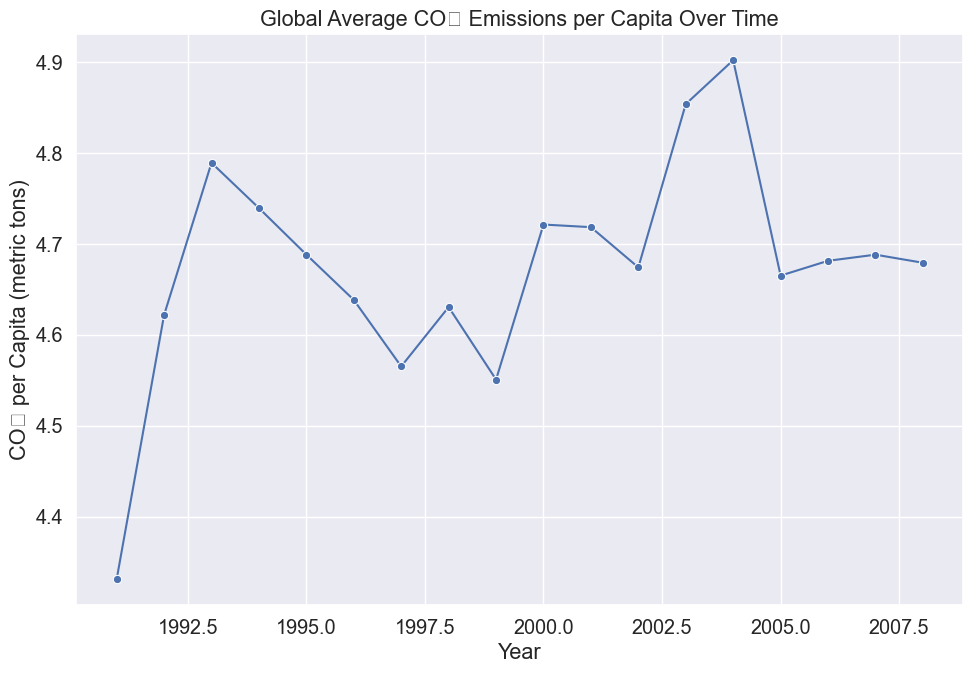

In [94]:
df_yearly_avg = data.groupby('year')['co2_per_cap'].mean().reset_index()

# Plot: Global average CO2 per capita over time
plt.figure(figsize=(10, 7))
sns.lineplot(data=df_yearly_avg, x='year', y='co2_per_cap', marker='o')
plt.title('Global Average CO₂ Emissions per Capita Over Time')
plt.ylabel('CO₂ per Capita (metric tons)')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\haris\AppData\Local\Temp\ipykernel_20256\3806975882.py:7: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
C:\Users\haris\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


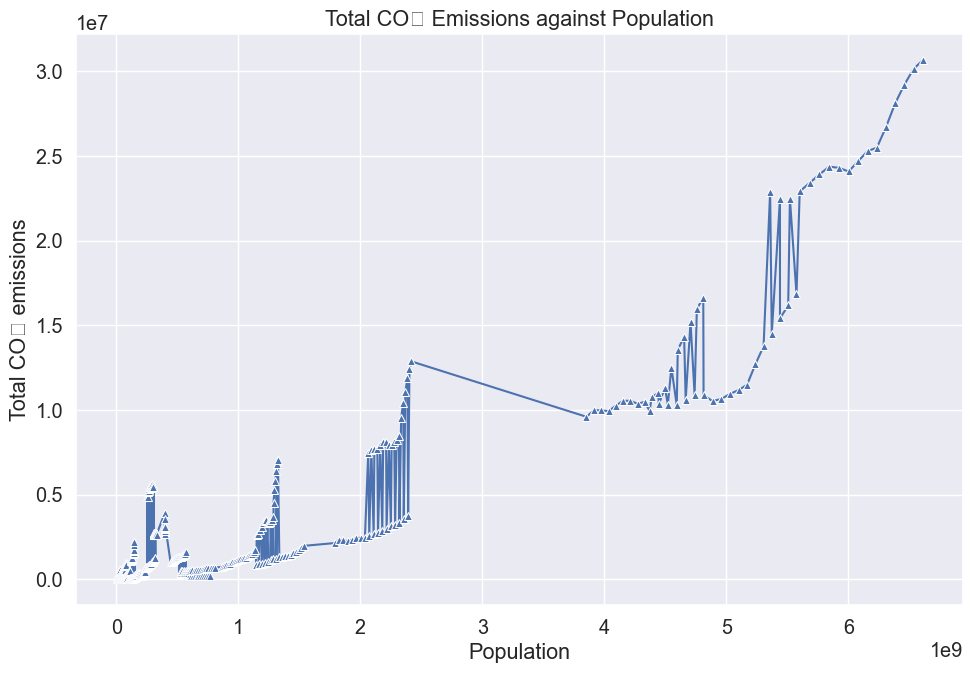

In [96]:
plt.figure(figsize=(10, 7))
sns.lineplot(data=data, x='pop', y='co2_ttl', marker='^')
plt.title('Total CO₂ Emissions against Population')
plt.ylabel('Total CO₂ emissions')
plt.xlabel('Population')
plt.grid(True)
plt.tight_layout()
plt.show()

In [98]:
data['en_ttl'] = data['en_per_gdp'] * data['gdp'] / 1000

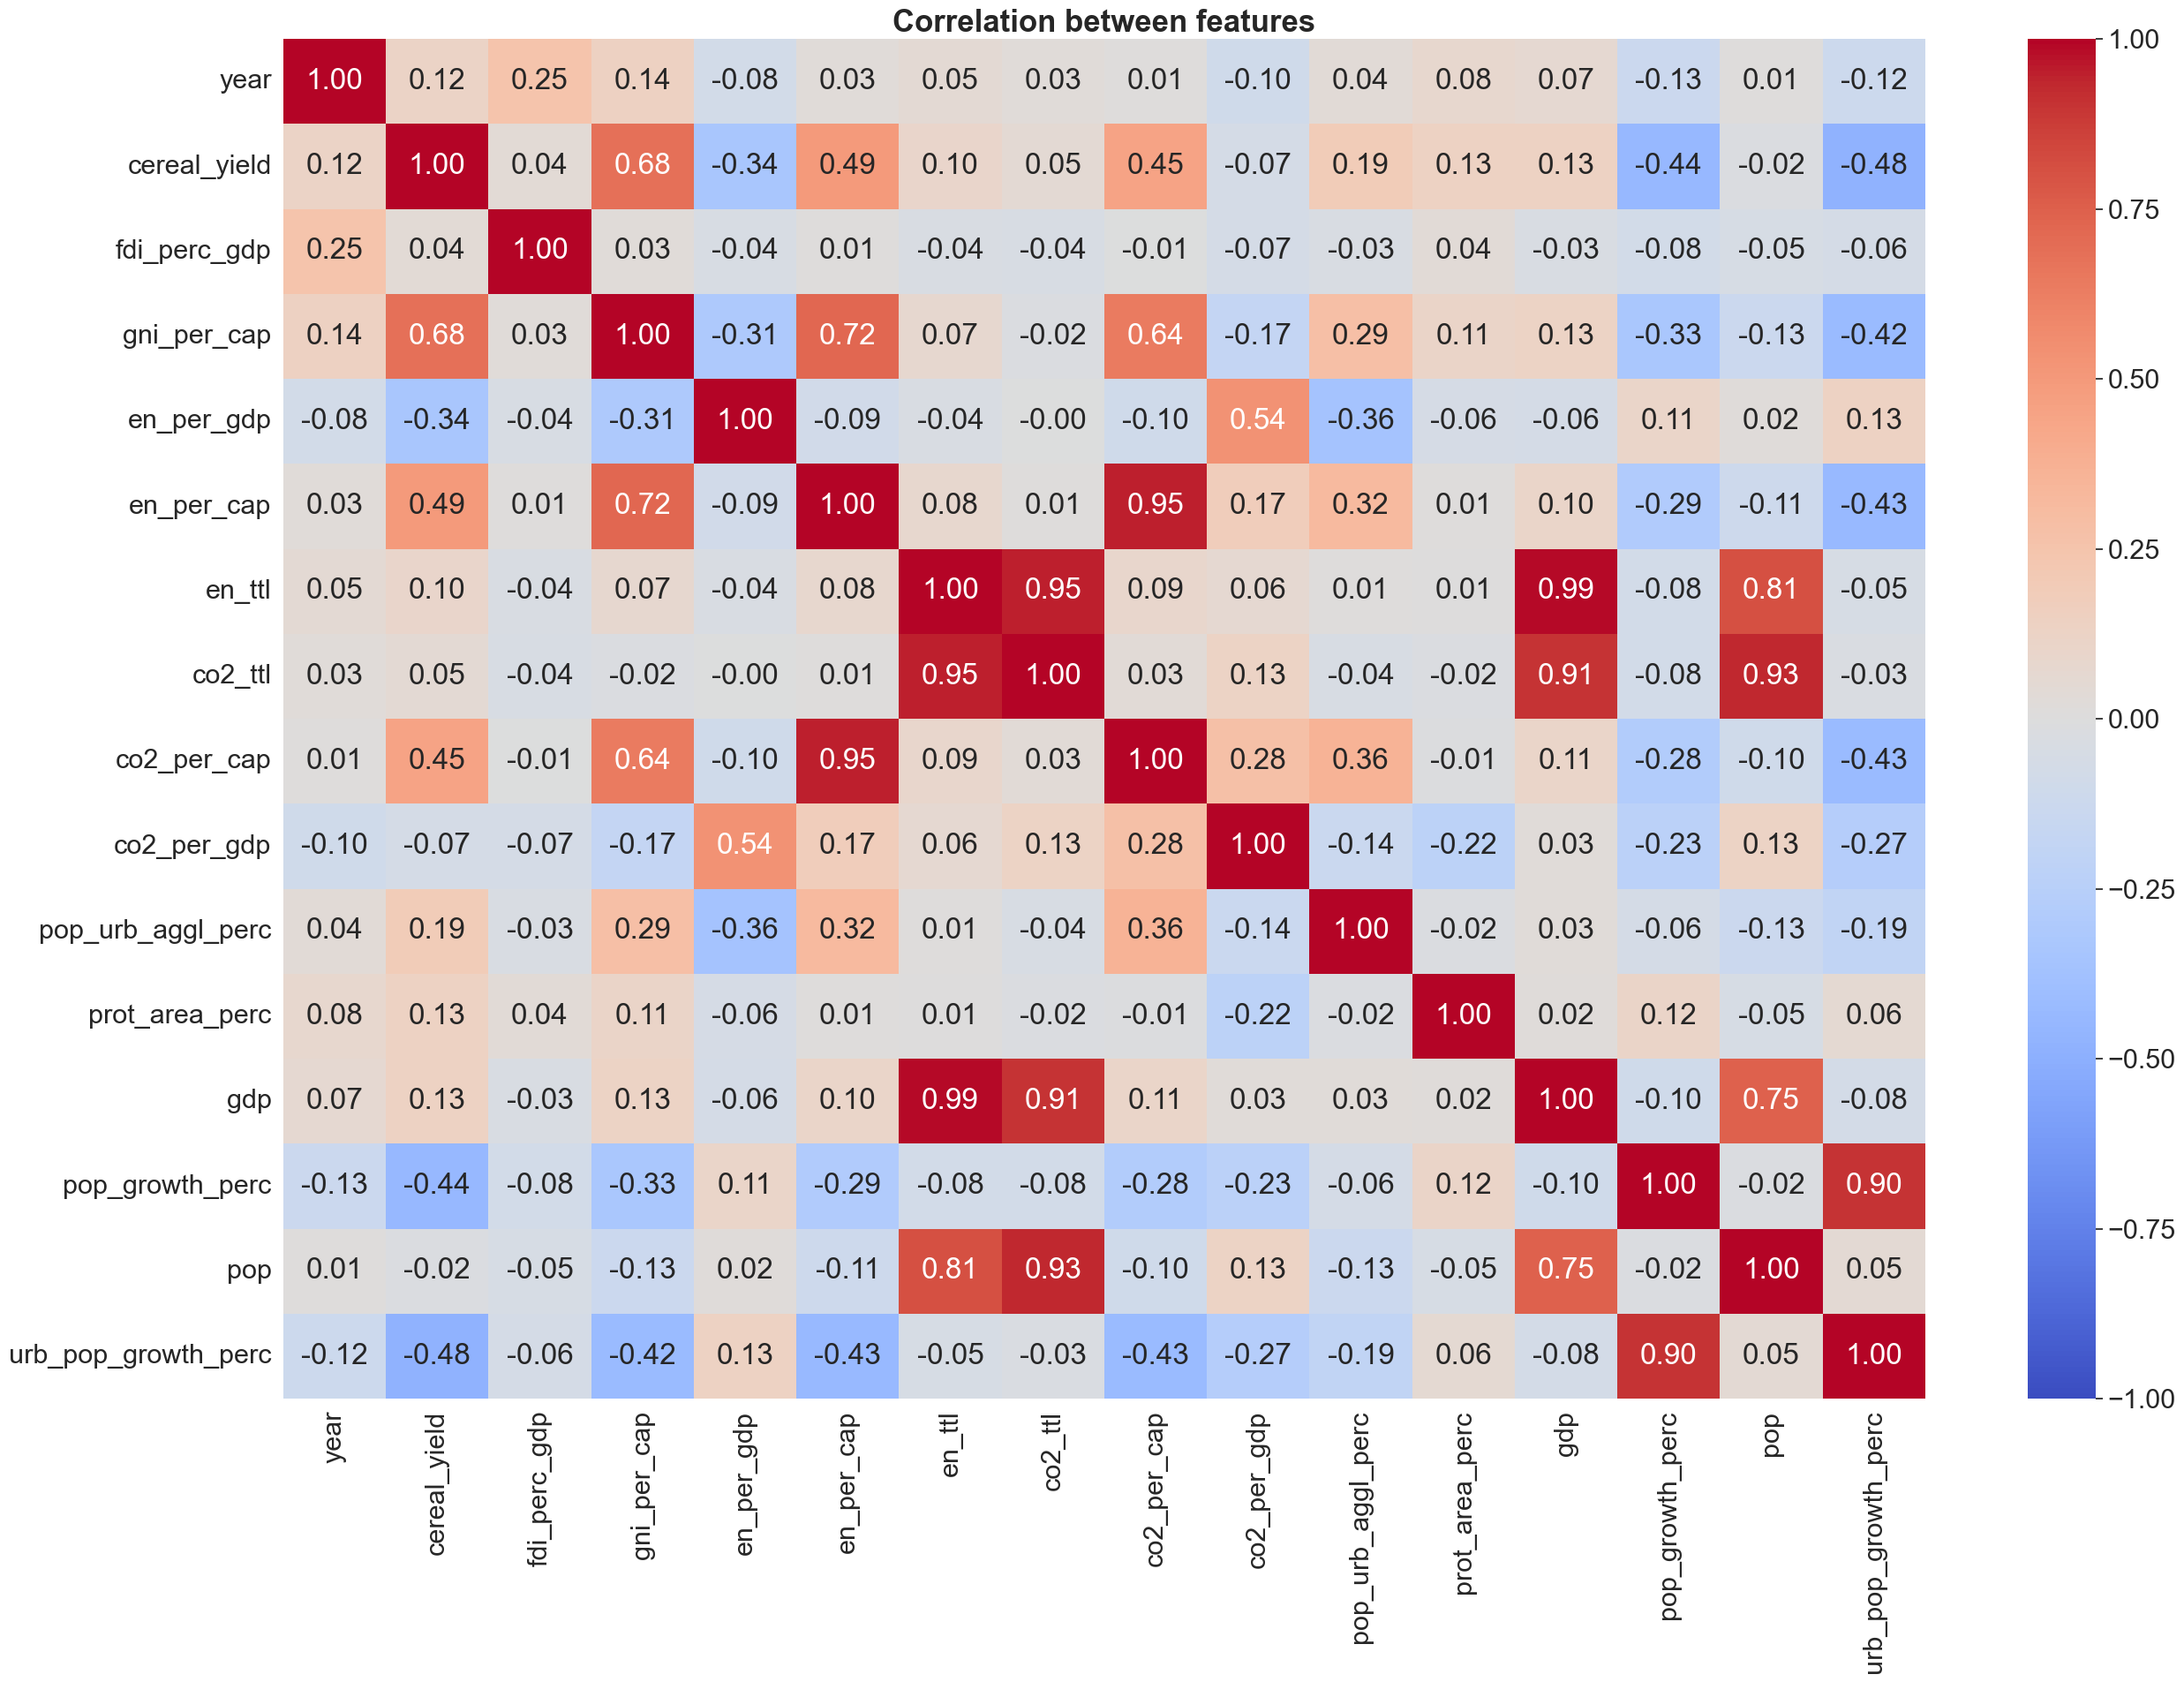

In [100]:
features_all = data[['country','year','cereal_yield','fdi_perc_gdp','gni_per_cap',
                     'en_per_gdp', 'en_per_cap', 'en_ttl', 'co2_ttl', 'co2_per_cap',
                     'co2_per_gdp', 'pop_urb_aggl_perc', 'prot_area_perc', 'gdp',
                     'pop_growth_perc', 'pop', 'urb_pop_growth_perc']]

# Correlation heatmap
sns.set_theme(font_scale=2)
plt.figure(figsize=(30, 20))
sns.heatmap(features_all.drop(['country'], axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f", 
            center=0, vmin=-1, vmax=1)
plt.title('Correlation between features', fontsize=25, weight='bold')
plt.show()

# Reset font size for smaller plots
sns.set_theme(font_scale=1)

In [102]:
features_for_vif = data[['cereal_yield','fdi_perc_gdp','gni_per_cap', 'en_per_cap', 'co2_per_cap',
                         'pop_urb_aggl_perc', 'prot_area_perc', 'gdp',  'pop_growth_perc', 'urb_pop_growth_perc']]

# VIF calculation
vif_data = pd.DataFrame()
vif_data["feature"] = features_for_vif.columns
vif_data["VIF"] = [variance_inflation_factor(features_for_vif.values, i)
                   for i in range(features_for_vif.shape[1])]
print("\nVariance Inflation Factor (VIF):")
print(vif_data)


Variance Inflation Factor (VIF):
               feature        VIF
0         cereal_yield   1.528133
1         fdi_perc_gdp   0.971334
2          gni_per_cap   2.910812
3           en_per_cap  12.579371
4          co2_per_cap  10.762323
5    pop_urb_aggl_perc   0.979676
6       prot_area_perc   1.022400
7                  gdp   1.106440
8      pop_growth_perc   6.336530
9  urb_pop_growth_perc   5.808288


In [104]:
features = features_all[['cereal_yield','fdi_perc_gdp','gni_per_cap', 'en_per_cap', 'co2_per_cap',
                         'pop_urb_aggl_perc', 'prot_area_perc', 'gdp',  'pop_growth_perc', 'urb_pop_growth_perc']]


In [106]:
labels_dict = {
    'gni_per_cap': 'GNI per capita [Atlas $]',
    'gdp': 'Gross Domestic Product [$]',
    'cereal_yield': 'Cereal yield [kg/ha]',
    'prot_area_perc': 'Nationally terrestrial protected areas [% of total land area]',
    'fdi_perc_gdp': 'Foreign Direct Investment [% of GDP]',
    'pop_urb_aggl_perc': 'Population in urban agglomerations > 1mln [%]',
    'urb_pop_growth_perc': 'Urban population growth [annual %]',
    'pop_growth_perc': 'Population growth [annual %]',
    'co2_per_cap': 'CO₂ emissions per capita [t]',
    'en_per_cap': 'Energy use per capita [kg oil eq]'
}


In [108]:
unique_countries = data['country'].unique()
print("\nUnique countries in the dataset:")
print(unique_countries)


Unique countries in the dataset:
['AGO' 'ARE' 'ARG' 'ARM' 'AUS' 'AUT' 'BGD' 'BGR' 'BLR' 'BOL' 'BRA' 'CAN'
 'CHE' 'CHL' 'CHN' 'CIV' 'CMR' 'COG' 'COL' 'CRI' 'CZE' 'DEU' 'DNK' 'DOM'
 'DZA' 'ECA' 'ECU' 'EGY' 'EMU' 'ESP' 'ETH' 'FIN' 'FRA' 'GBR' 'GHA' 'GRC'
 'GTM' 'HND' 'HUN' 'IDN' 'IND' 'IRL' 'IRN' 'ISR' 'ITA' 'JOR' 'JPN' 'KAZ'
 'KEN' 'KOR' 'LAC' 'LIC' 'LMC' 'LMY' 'MAR' 'MEX' 'MIC' 'MNA' 'MOZ' 'MYS'
 'NGA' 'NLD' 'NZL' 'PAK' 'PAN' 'PER' 'PHL' 'POL' 'PRT' 'PRY' 'ROM' 'RUS'
 'SAS' 'SAU' 'SDN' 'SEN' 'SLV' 'SSA' 'SWE' 'SYR' 'TGO' 'THA' 'TUR' 'TZA'
 'UKR' 'UMC' 'URY' 'USA' 'UZB' 'VEN' 'VNM' 'WLD' 'YEM' 'ZAF' 'ZAR' 'ZMB']


C:\Users\haris\AppData\Local\Temp\ipykernel_20256\920885443.py:11: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
C:\Users\haris\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


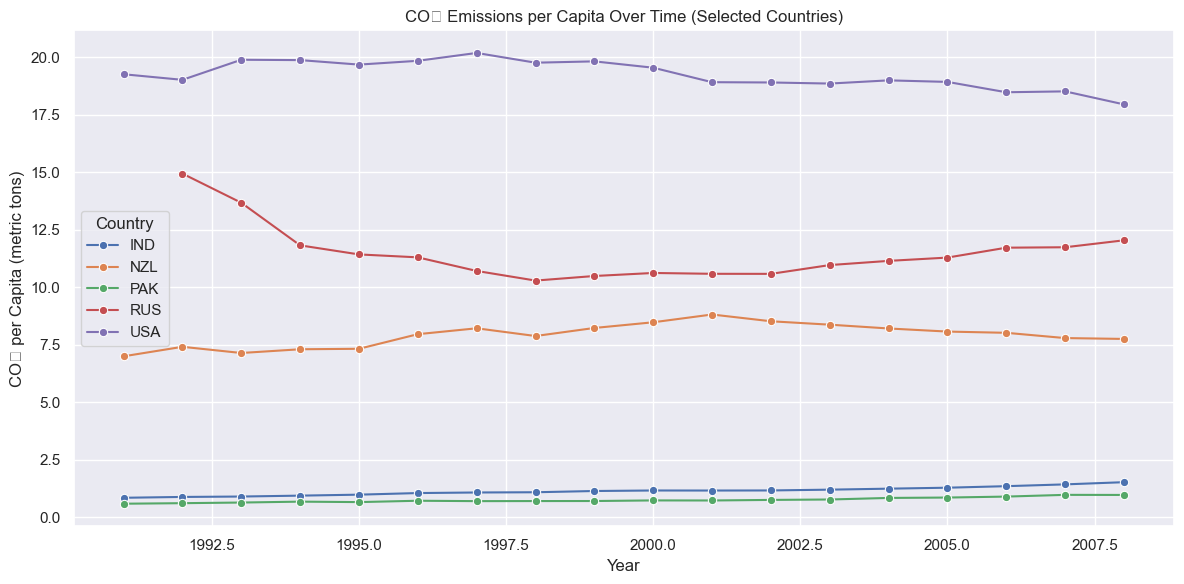

In [110]:
selected_countries = ['IND', 'USA', 'PAK', 'RUS', 'NZL']
df_selected = data[data['country'].isin(selected_countries)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_selected, x='year', y='co2_per_cap', hue='country', marker='o')
plt.title('CO₂ Emissions per Capita Over Time (Selected Countries)')
plt.ylabel('CO₂ per Capita (metric tons)')
plt.xlabel('Year')
plt.legend(title='Country')
plt.grid(True)
plt.tight_layout()
plt.show()

In [112]:
chosen_countries = ['IND', 'LMC', 'LMY', 'MAR', 'MEX', 'MIC', 'MNA', 'MOZ', 'MYS',
    'NGA', 'NLD', 'NZL', 'PAK', 'PAN', 'PER', 'PHL', 'PRT', 'PRY',
    'ROM', 'SAS', 'SAU', 'SDN', 'SEN', 'SLV', 'SSA', 'SWE', 'SYR',
    'TGO', 'THA', 'TUR', 'TZA', 'UMC', 'URY', 'USA', 'VEN', 'VNM',
    'WLD', 'ZAF', 'ZAR', 'ZMB', 'ECA', 'POL', 'RUS', 'UKR', 'YEM',
    'ETH', 'BEL']


features_chosen = features_all[features_all['country'].isin(chosen_countries)]

In [ ]:
# Set Seaborn theme
sns.set_theme(font_scale=1.3)

# Pairplot for multivariate exploration
sns.pairplot(data=features_chosen, hue='country')

In [ ]:
feature_cols = ['country', 'cereal_yield', 'fdi_perc_gdp', 'gni_per_cap', 'en_per_cap', 
                'pop_urb_aggl_perc', 'prot_area_perc', 'gdp', 'pop_growth_perc', 
                'urb_pop_growth_perc', 'co2_per_cap']

# Create a copy for plotting to avoid modifying the original data
features_for_plot = data[feature_cols].copy()

# Remove outliers or specific country if needed
features_for_plot = features_for_plot[features_for_plot['country'] != 'ARE']

In [ ]:

sns.set_theme(style="whitegrid", font_scale=2)

cmap = sns.cubehelix_palette(rot=-.2, as_cmap=True)

g = sns.relplot(
    data=features_for_plot,
    x="urb_pop_growth_perc",
    y="co2_per_cap",
    hue="en_per_cap",
    size="pop_urb_aggl_perc",
    palette=cmap,
    sizes=(10, 200),
    height=10,
    aspect=4/3
)

# Label axes with human-readable names
g.ax.set_xlabel(labels_dict['urb_pop_growth_perc'])
g.ax.set_ylabel(labels_dict['co2_per_cap'])